# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

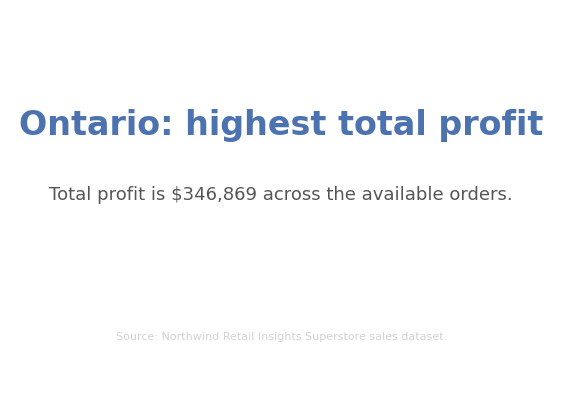

In [7]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()
best_profit = region_totals.max()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# Primary: largest, boldest, colored
ax.text(0.5, 0.70, f"{best_region}: highest total profit", ha="center", va="center",
        fontsize=24, fontweight="bold", color="#4C72B0")

# Secondary: supporting sentence
ax.text(0.5, 0.52, f"Total profit is ${best_profit:,.0f} across the available orders.",
        ha="center", va="center", fontsize=13, color="#555555")

# Tertiary: source footnote
ax.text(0.5, 0.15, "Source: Northwind Retail Insights Superstore sales dataset.",
        ha="center", va="center", fontsize=8, color="lightgray")

plt.show()


**Your answer:**

My eyes land first on the large, bold colored primary statement, then on the medium-sized supporting sentence, and finally on the small footnote. In a two-second glance, the key fact I would retain is which region has the highest total profit.


## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

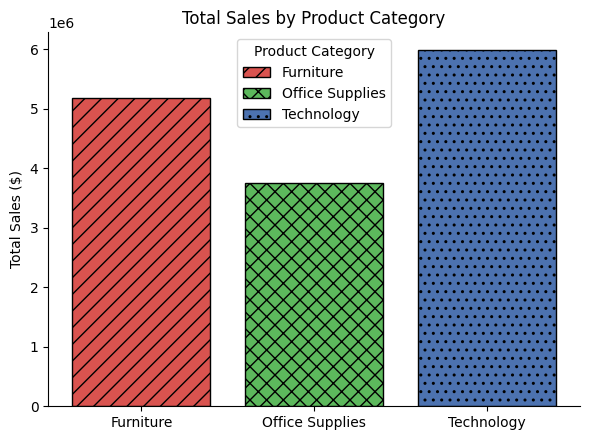

In [8]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for i, cat in enumerate(cat_sales.index):
    ax.bar(i, cat_sales[cat], color=colors[cat], hatch=hatches[cat],
           edgecolor="black", label=cat)

ax.set_xticks(range(len(cat_sales)))
ax.set_xticklabels(cat_sales.index)
ax.set_ylabel("Total Sales ($)")
ax.set_title("Total Sales by Product Category")
ax.legend(title="Product Category")
plt.tight_layout()
plt.show()


**Your answer:**

Using only color can fail because people with color-vision deficiencies may not reliably distinguish the categories, and grayscale printing can remove the luminance/color differences that make the categories separable. Redundant coding with hatch patterns keeps the categories distinguishable in both cases.


## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

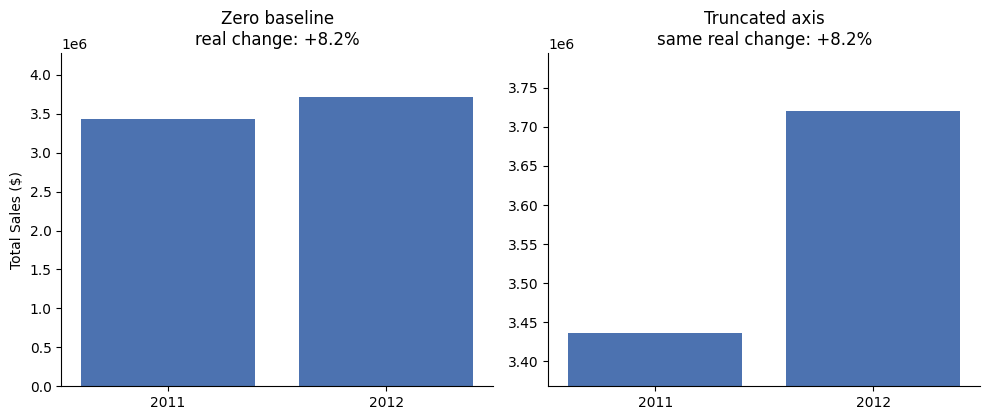

Real change from 2011 to 2012: +8.2%


In [9]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.loc[y1], yearly_sales.loc[y2]
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# Zero-baseline version
axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(0, max(v1, v2) * 1.15)
axes[0].set_title(f"Zero baseline\nreal change: {pct_change:+.1f}%")
axes[0].set_ylabel("Total Sales ($)")

# Truncated version
axes[1].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
low = min(v1, v2) * 0.98
high = max(v1, v2) * 1.02
axes[1].set_ylim(low, high)
axes[1].set_title(f"Truncated axis\nsame real change: {pct_change:+.1f}%")

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")


**Your answer:**

I would flag the truncated-axis panel if it were used alone because the shortened y-axis makes a relatively small year-over-year change occupy most of the visual height, which can make the difference look much larger than it really is.


## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales increased from $3,436,817 in 2011 to $3,719,964 in 2012, a +8.2% change.
INTERPRETIVE: Sales increased +8.2% from 2011 to 2012; the rebound may reflect the new strategy, but this dataset alone does not establish causation.


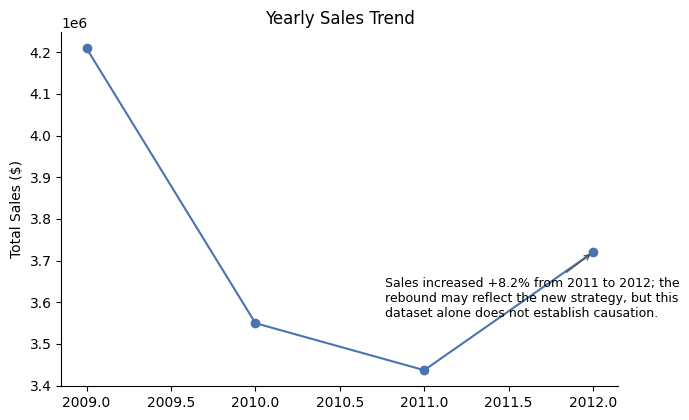

In [10]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

descriptive_version = f"Sales increased from ${yearly_sales.loc[y1]:,.0f} in {y1} to ${yearly_sales.loc[y2]:,.0f} in {y2}, a {pct_change:+.1f}% change."
interpretive_version = f"Sales increased {pct_change:+.1f}% from {y1} to {y2}; the rebound may reflect the new strategy, but this dataset alone does not establish causation."

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
ax.annotate(interpretive_version, xy=(y2, v2), xytext=(-150, -45), textcoords="offset points",
            ha="left", fontsize=9, wrap=True,
            arrowprops=dict(arrowstyle="->", color="#555555"))
ax.set_ylabel("Total Sales ($)")
ax.set_title("Yearly Sales Trend")
plt.tight_layout()
plt.show()


**Your answer:**

To justify the original claim, we would need evidence that isolates the strategy as the cause of the improvement, such as a controlled experiment or credible comparison with similar regions/stores that did not receive the strategy. We would also need enough time and outcome data to rule out seasonality, market changes, pricing changes, and other confounders.


**Your final recommendation here:**

The most urgent fix is the axis correction because a misleading scale can immediately distort a manager’s perception of the magnitude of change. The Ethical Visualization Audit question “Does the axis/scale choice honestly represent the magnitude of the difference?” applies directly to Task 3: the truncated axis exaggerates the visual size of a modest year-over-year change. The annotation review in Task 4 also shows why wording must match what the data can support rather than implying causation. I recommend a permanent pre-publication review checklist that requires a zero-baseline/scale check, accessibility check, and annotation-evidence check before any chart is released.
